In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# loading dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# creating target column
# 1 = Pass, 0 = Fail
df["pass_fail"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["pass_fail"].value_counts())

Dataset shape: (395, 34)

Target distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64


In [3]:
# Feature selection
# selecting features based on our EDA findings
# these are the variables that showed strongest relationship with G3
features = ["studytime", "failures", "absences", "G1", "G2", "Medu", "Fedu", "higher", "internet"]

# higher and internet are categorical (yes/no) so we need to encode them
# label encoder converts yes/no to 1/0
le = LabelEncoder()
df["higher_encoded"] = le.fit_transform(df["higher"])
df["internet_encoded"] = le.fit_transform(df["internet"])

#final features list with encoded columns
features = ["studytime", "failures", "absences", "G1", "G2", "Medu", "Fedu", "higher_encoded", "internet_encoded"]

# x = input features, y = target variable
x = df[features]
y = df["pass_fail"]

print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (395, 9)
Target shape: (395,)


In [4]:
# Train test split

# splitting data into training and testing sets
# test_size=0.2 means 80% training, 20% testing
# random_state=42 ensures we get same split every time we run

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Training samples: 316
Testing samples: 79


In [5]:
# Train the model
# trainging logistic regression model
# max_iter=1000 gives the model enough iterations to converge
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

print("Model trained successfully")

Model trained successfully


In [6]:
# Evaluate the model
# making predictions on test data
y_pred = model.predict(x_test)

# accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(accuracy * 100, 2)}%")

# detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Accuracy: 88.61%

Classification Report:
              precision    recall  f1-score   support

        Fail       0.82      0.85      0.84        27
        Pass       0.92      0.90      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.88      0.87        79
weighted avg       0.89      0.89      0.89        79



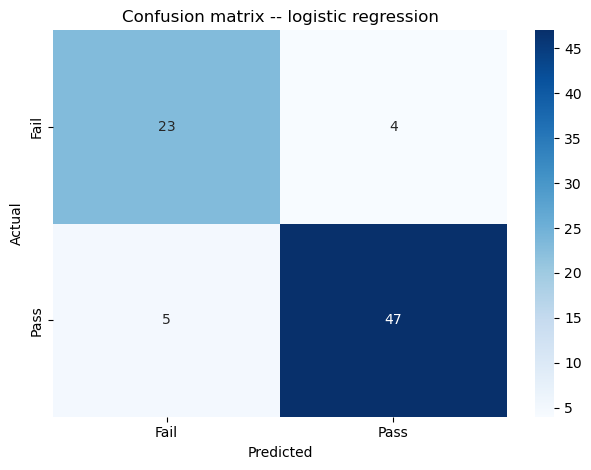

In [9]:
# Confusion Matrix

# confsuion matrix shows exactly where the model is right and wrong
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fail", "Pass"], yticklabels=["Fail", "Pass"])

plt.title("Confusion matrix -- logistic regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("../screenshots/confusion_matrix.png", dpi=150)
plt.show()

In [10]:
# what the numbers mean:
# top left = correctly predicted fail (true negatives)
# top right = predicted pass but actually failed (false positives)
# bottom left = predicted fail but actually passed (false negatives)
# bottom right = correctly predicted pass (true positives)

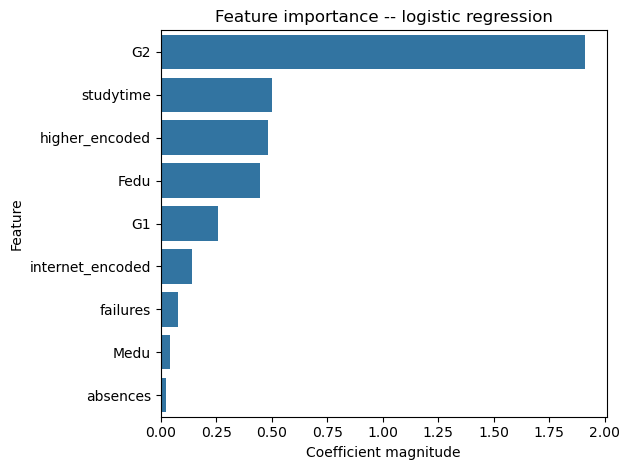

In [11]:
# Feature Importance - which variables influenced the model most
importance = pd.DataFrame({
    "feature": features,
    "importance": abs(model.coef_[0])
})

# sort by importance
importance = importance.sort_values("importance", ascending=False)

sns.barplot(data=importance, x="importance", y="feature", errorbar=None)

plt.title("Feature importance -- logistic regression")
plt.xlabel("Coefficient magnitude")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../screenshots/feature_importance.png", dpi=150)
plt.show()

In [12]:
# insight
# G2 dominates all other features by a large margin
# this confirms that period 2 grade is the best early warning signal
# failures ranks low because G2 already captures its effect indirectly
# for a school intervention system -- checking G2 results is the most actionable step